# Section 0: Import Library

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


# Section 1: Data Load & Cleaning

In [4]:
# data_2021 = pd.read_csv("./Dataset/verify_BC_datasets/2021/PM25_with_geo_2021.csv")
data_2022 = pd.read_csv("./Dataset/verify_BC_datasets/2022/PM25_with_geo_2022.csv")
data_2023 = pd.read_csv("./Dataset/verify_BC_datasets/2023/PM25_with_geo_2023.csv")
data_2024 = pd.read_csv("./Dataset/verify_BC_datasets/2024/PM25_with_geo_2024.csv")
data_2025 = pd.read_csv("./Dataset/verify_BC_datasets/2025/PM25_with_geo_2025.csv")

all_raw_dataframes = [data_2022, data_2023, data_2024, data_2025]

From the results below, I noticed that 2025 has much less data than the other years. We need further investigation. We also need to convert the data types into the correct datetime format.

In [5]:
# Check the datatype shape & info
for i, df in enumerate(all_raw_dataframes, start=2022):
    print(f"Year {i}: DataFrame shape: {df.shape}")
    print()
    print(df.info())

Year 2022: DataFrame shape: (1191360, 5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1191360 entries, 0 to 1191359
Data columns (total 5 columns):
 #   Column     Non-Null Count    Dtype  
---  ------     --------------    -----  
 0   Datetime   1191360 non-null  object 
 1   Station    1191360 non-null  object 
 2   PM25       1105225 non-null  float64
 3   Latitude   1191360 non-null  float64
 4   Longitude  1191360 non-null  float64
dtypes: float64(3), object(2)
memory usage: 45.4+ MB
None
Year 2023: DataFrame shape: (1165080, 5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1165080 entries, 0 to 1165079
Data columns (total 5 columns):
 #   Column     Non-Null Count    Dtype  
---  ------     --------------    -----  
 0   Datetime   1165080 non-null  object 
 1   Station    1165080 non-null  object 
 2   PM25       1029679 non-null  float64
 3   Latitude   1165080 non-null  float64
 4   Longitude  1165080 non-null  float64
dtypes: float64(3), object(2)
memory usage: 44

In [6]:
# Turn Datetime column into datetime type
for df in all_raw_dataframes:
    df["Datetime"] = pd.to_datetime(df["Datetime"], errors="coerce")
    df["Station"] = df["Station"].astype(str)
    
    # print after conversion to check if it worked
    print(f"Year {df['Datetime'].dt.year.iloc[0]}:\n{df.dtypes}\n")

Year 2022:
Datetime     datetime64[ns]
Station              object
PM25                float64
Latitude            float64
Longitude           float64
dtype: object

Year 2023:
Datetime     datetime64[ns]
Station              object
PM25                float64
Latitude            float64
Longitude           float64
dtype: object

Year 2024:
Datetime     datetime64[ns]
Station              object
PM25                float64
Latitude            float64
Longitude           float64
dtype: object

Year 2025:
Datetime     datetime64[ns]
Station              object
PM25                float64
Latitude            float64
Longitude           float64
dtype: object



Here is the corrected and more natural version:

Check for duplicates in each year where the same date and the same station have different values. We keep the older record to ensure the data remains consistent. This logic makes sense if we consider the possibility that someone updated a value but forgot to remove the previous entry.

After removing duplicates, the results make more sense for 2022, 2023, and 2025, as they now have consistent values. However, 2024 still differs, which could be due to the leap year. As for 2021, the discrepancy might be because some stations do not have sufficient data. We need to identify those stations.

In [7]:
# Check the duplicate for each year
for i, df in enumerate(all_raw_dataframes, start=2022):
    duplicate_count = df.drop_duplicates(subset=['Datetime', 'Station'], keep="last").shape[0]
    print(f"Year {i}: Number of duplicate rows: {duplicate_count}")
    
        
    # remove duplicates
    df.drop_duplicates(subset=['Datetime', 'Station'], keep="last", inplace=True)
        
    # After removing duplicates, check how many rows are left.
    print(f"Year {i}: Number of rows after removing duplicates: {df.drop_duplicates().shape[0]}\n")



Year 2022: Number of duplicate rows: 551880
Year 2022: Number of rows after removing duplicates: 551880

Year 2023: Number of duplicate rows: 551880
Year 2023: Number of rows after removing duplicates: 551880

Year 2024: Number of duplicate rows: 553392
Year 2024: Number of rows after removing duplicates: 553392

Year 2025: Number of duplicate rows: 551880
Year 2025: Number of rows after removing duplicates: 551880



There are four stations—**Langdale Elementary**, **Quesnel Johnston Avenue**, **Sparwood Centennial Square**, and **Elkford Rocky Mountain Elementary School**—with late-starting data. We can remove them because they are from different regions in British Columbia, so dropping them should not significantly reduce coverage within any single region.


In [8]:
# # Find the earliest record time ("start date") for each station in 2021
# dataframe_2021 = all_raw_dataframes[0]  # DataFrame for year 2021
# station_start_dates = dataframe_2021.groupby("Station")["Datetime"].min().sort_values()

# print("--- 2021 Station Start Dates (Late Bloomers) ---")
# late_stations = station_start_dates[station_start_dates > pd.Timestamp("2021-01-02")]
# print(late_stations)
# print(f"{late_stations.index.tolist()}")


In [9]:
# # Remove all the data that came from those late-starting stations in all years
# late_station_names = late_stations.index.tolist()
# for df in all_raw_dataframes:
#     df.drop(df[df["Station"].isin(late_station_names)].index, inplace=True)

In [10]:
for i, df in enumerate(all_raw_dataframes, start=2022):
    print(f"\nYEAR: {i}")
    print(f"Records: {len(df)}")
    if not df.empty:
        print(f"Time Range: {df['Datetime'].min()} to {df['Datetime'].max()}")
        print(f"Missing Values Percentage: {df.isna().sum().sum() / df.size * 100:.2f}%")
        
        # print total unique stations after removing late bloomers
        print(f"Total Unique Stations: {df['Station'].nunique()}")



YEAR: 2022
Records: 551880
Time Range: 2022-01-01 01:00:00 to 2023-01-01 00:00:00
Missing Values Percentage: 1.21%
Total Unique Stations: 63

YEAR: 2023
Records: 551880
Time Range: 2023-01-01 01:00:00 to 2024-01-01 00:00:00
Missing Values Percentage: 1.82%
Total Unique Stations: 63

YEAR: 2024
Records: 553392
Time Range: 2024-01-01 01:00:00 to 2025-01-01 00:00:00
Missing Values Percentage: 0.68%
Total Unique Stations: 63

YEAR: 2025
Records: 551880
Time Range: 2025-01-01 01:00:00 to 2026-01-01 00:00:00
Missing Values Percentage: 1.33%
Total Unique Stations: 63


We would like to investigate the missing values. In this case, the total number of missing values could be misleading. If a station has significantly more missing data than other stations, it may need to be dropped.

In [11]:
# %% Check missing values by station
print("--- Missing PM2.5 Percentage by Station (> 0%) ---")

for i, df in enumerate(all_raw_dataframes, start=2022):
    
    # print year
    print(f"\nYEAR: {i}\n")
    
    # 1. Group by 'Station' and calculate the percentage of NaN values in 'PM25'
    # We use .isna().mean() * 100 to get the percentage
    missing_stats = df.groupby('Station')['PM25'].apply(lambda x: x.isna().mean() * 100)
    
    # 2. Filter: Keep only stations with > 0% missing data
    missing_stats = missing_stats[missing_stats > 0]
    
    # 3. Sort: From Big to Small (Descending)
    missing_stats = missing_stats.sort_values(ascending=False)
    
    # 4. Print the result
    if not missing_stats.empty:
        # Print with 2 decimal places and a % sign
        print(missing_stats.apply(lambda x: f"{x:.2f}%"))
    else:
        print("✅ No stations have missing PM2.5 values (NaNs) in the recorded rows.")
        
    print("\n" + "-"*50)

--- Missing PM2.5 Percentage by Station (> 0%) ---

YEAR: 2022

Station
Valemount                           68.49%
Victoria Topaz                      62.32%
Courtenay Elementary School         57.41%
Prince George Plaza 400             30.19%
Sparwood Centennial Square          14.16%
                                     ...  
Fort St John Key Learning Centre     0.41%
Vernon Science Centre                0.31%
Kamloops Federal Building            0.27%
Smithers Muheim Memorial             0.21%
Kelowna KLO Road                     0.16%
Name: PM25, Length: 63, dtype: object

--------------------------------------------------

YEAR: 2023

Station
Houston Firehall                87.00%
Victoria Topaz                  57.88%
Duncan College Street           55.32%
Colwood City Hall               51.99%
Valemount                       35.24%
                                 ...  
Abbotsford Central               0.64%
Tsawwassen                       0.42%
Abbotsford A Columbia Street    

Based on the results above, some stations have more than 20% missing data. In general, when more than 20% of a dataset is missing, it becomes difficult to impute reliably. Therefore, we will remove these stations for all years to ensure data consistency.

In [12]:
# %% Remove stations with > 20% missing data
print("--- Removing Stations with > 20% Missing Data ---")

# 1. Identify stations to remove
stations_to_remove = set()


for i, df in enumerate(all_raw_dataframes, start=2022):
    # Calculate missing percentage per station
    missing_series = df.groupby('Station')['PM25'].apply(lambda x: x.isna().mean())
    
    # Identify stations with > 20% missing
    bad_stations = missing_series[missing_series > 0.20].index.tolist()
    
    if bad_stations:
        print(f"Year {i}: Found {len(bad_stations)} stations with > 20% missing data.")
        stations_to_remove.update(bad_stations)

# 2. Print summary of stations to be removed
print(f"\n🚫 Total Unique Stations to Remove: {len(stations_to_remove)}")
print(f"Stations: {sorted(list(stations_to_remove))}")

# 3. Remove them from all datasets
if stations_to_remove:
    for i, df in enumerate(all_raw_dataframes, start=2022):
        original_count = len(df)
        original_count = len(df)
        
        # Filter out the bad stations
        # We use ~ (tilde) to negate the condition (Keep stations NOT in the remove list)
        all_raw_dataframes[i - 2022] = df[~df['Station'].isin(stations_to_remove)]
        
        dropped_count = original_count - len(all_raw_dataframes[i - 2022])
        print(f"✅ Year {i}: Dropped {dropped_count} rows (removed {len(stations_to_remove)} stations).")

# 4. Final check of remaining stations
if all_raw_dataframes:
    first_year = 2022
    remaining_stations = all_raw_dataframes[0]["Station"].nunique()
    print(f"\n🎉 Final Common Station Count: {remaining_stations}")

--- Removing Stations with > 20% Missing Data ---


Year 2022: Found 4 stations with > 20% missing data.
Year 2023: Found 7 stations with > 20% missing data.
Year 2024: Found 2 stations with > 20% missing data.
Year 2025: Found 3 stations with > 20% missing data.

🚫 Total Unique Stations to Remove: 13
Stations: ['Colwood City Hall', 'Courtenay Elementary School', 'Crofton Elementary', 'Duncan College Street', 'Duncan Deykin Avenue', 'Houston Firehall', 'Nanaimo Labieux Road', 'North Vancouver Second Narrows', 'Prince George Plaza 400', 'Quesnel Johnston Avenue', 'Terrace Skeena Middle School', 'Valemount', 'Victoria Topaz']
✅ Year 2022: Dropped 113880 rows (removed 13 stations).
✅ Year 2023: Dropped 113880 rows (removed 13 stations).
✅ Year 2024: Dropped 114192 rows (removed 13 stations).
✅ Year 2025: Dropped 113880 rows (removed 13 stations).

🎉 Final Common Station Count: 50


In [13]:
# %% Check missing values by station
print("--- Missing PM2.5 Percentage by Station (> 0%) ---")

for i, df in enumerate(all_raw_dataframes, start=2022):
    
    # print year
    print(f"\nYEAR: {i}\n")
    
    # 1. Group by 'Station' and calculate the percentage of NaN values in 'PM25'
    # We use .isna().mean() * 100 to get the percentage
    missing_stats = df.groupby('Station')['PM25'].apply(lambda x: x.isna().mean() * 100)
    
    # 2. Filter: Keep only stations with > 0% missing data
    missing_stats = missing_stats[missing_stats > 0]
    
    # 3. Sort: From Big to Small (Descending)
    missing_stats = missing_stats.sort_values(ascending=False)
    
    # 4. Print the result
    if not missing_stats.empty:
        # Print with 2 decimal places and a % sign
        print(missing_stats.apply(lambda x: f"{x:.2f}%"))
    else:
        print("✅ No stations have missing PM2.5 values (NaNs) in the recorded rows.")
        
    print("\n" + "-"*50)

--- Missing PM2.5 Percentage by Station (> 0%) ---

YEAR: 2022

Station
Sparwood Centennial Square                  14.16%
Elk Falls Dogwood                           12.58%
Whistler Meadow Park                        11.22%
Prince Rupert Fairview                       8.52%
Mission School Works Yard                    8.03%
Vanderhoof Courthouse                        6.16%
Kitimat Haul Road                            5.14%
Kitimat Haisla Village                       4.67%
Kitimat Whitesail                            3.92%
Fort St John North Camp C                    3.69%
Crofton Substation                           3.55%
Elkford Rocky Mountain Elementary School     3.53%
Harmac Cedar Woobank                         3.28%
Kitimat Riverlodge                           3.13%
Pitt Meadows Meadowlands School              3.06%
Hope Airport                                 2.76%
Surrey East                                  2.56%
Peace Valley Attachie Flat Upper Terrace     2.56%
Fort St Jo

## 1. Define Distance Metric

We first define the **Haversine Formula**, which calculates the precise "Great Circle" distance between two points on the Earth's surface. This is critical for accurate spatial weighting in high-latitude regions like BC.


In [14]:
def haversine_matrix(coords):
    """
    Calculates the Great Circle distance between multiple points on Earth.
    
    Args:
        coords: Numpy array of shape (N, 2) containing [[Lat, Lon], ...] in decimal degrees.
    
    Returns:
        N x N matrix of distances in Kilometers.
    """
    R = 6371.0  # Earth radius in kilometers
    
    # Convert degrees to radians
    rads = np.radians(coords)
    lat = rads[:, 0][:, np.newaxis]
    lon = rads[:, 1][:, np.newaxis]
    
    # Vectorized Haversine formula
    dlat = lat - lat.T
    dlon = lon - lon.T
    a = np.sin(dlat / 2)**2 + np.cos(lat) * np.cos(lat.T) * np.sin(dlon / 2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    
    return R * c


## 2. Define the Imputation Function

This is the core engine of the pipeline. It takes a single year's dataframe and applies the three-step imputation logic sequentially.


In [15]:
def rigorous_imputation_pipeline(df, year_label):
    """
    Executes the 3-stage imputation pipeline:
    1. Temporal Forward Fill (Limit=1hr) -> Fixes micro-gaps.
    2. Spatial IDW (Haversine) -> Fixes macro-gaps using neighbors.
    3. Linear Interpolation -> Final cleanup for network-wide outages.
    """
    df = df.copy()
    
    # Ensure Datetime is properly formatted and sorted
    df['Datetime'] = pd.to_datetime(df['Datetime'], errors='coerce')
    df = df.sort_values(['Station', 'Datetime'])
    
    initial_missing = df['PM25'].isna().sum()
    if initial_missing == 0:
        print(f"[{year_label}] ✅ Data is already complete.")
        return df

    # --- Step 1: Temporal Forward Fill (Limit 1 hour) ---
    # We only fill gaps of 1 hour to preserve data integrity (no future data used).
    df['PM25'] = df.groupby('Station')['PM25'].ffill(limit=1)
    missing_s1 = df['PM25'].isna().sum()
    
    # --- Step 2: Spatial IDW (Haversine Distance) ---
    if missing_s1 > 0:
        # Pivot to wide format: Index=Time, Columns=Stations
        pivot = df.pivot_table(index='Datetime', columns='Station', values='PM25')
        
        # Prepare coordinates aligned with pivot columns
        stations_info = df[['Station', 'Latitude', 'Longitude']].drop_duplicates('Station').set_index('Station')
        stations_info = stations_info.loc[pivot.columns]
        coords = stations_info[['Latitude', 'Longitude']].values
        
        # Calculate Distance Matrix
        dists = haversine_matrix(coords)
        np.fill_diagonal(dists, np.inf) # Ignore self-distance
        
        # Calculate Weights (Inverse Distance Squared)
        weights = 1.0 / (dists + 1e-6)**2 
        
        # Vectorized Imputation
        values = pivot.values
        # Mask: 1 where data exists, 0 where NaN
        mask_present = (~np.isnan(values)).astype(float)
        values_zeroed = np.nan_to_num(values)
        
        # Weighted Average Calculation
        with np.errstate(divide='ignore', invalid='ignore'):
            numerator = values_zeroed @ weights.T
            denominator = mask_present @ weights.T
            imputed = numerator / denominator
        
        # Fill missing values in the pivot table
        pivot_filled = pivot.copy()
        mask_missing = pivot.isna()
        pivot_filled[mask_missing] = pd.DataFrame(imputed, index=pivot.index, columns=pivot.columns)[mask_missing]
        
        # Convert back to long format (melt) and merge
        df_filled = pivot_filled.reset_index().melt(id_vars='Datetime', var_name='Station', value_name='PM25_Filled')
        df = pd.merge(df, df_filled, on=['Datetime', 'Station'], how='left')
        
        # Apply the filled values
        df['PM25'] = df['PM25'].fillna(df['PM25_Filled'])
        df = df.drop(columns=['PM25_Filled'])
    
    missing_s2 = df['PM25'].isna().sum()

    # --- Step 3: Final Cleanup (Linear Interpolation) ---
    # Handles rare cases where ALL stations are down simultaneously (IDW fails).
    if missing_s2 > 0:
        df['PM25'] = df.groupby('Station')['PM25'].transform(
            lambda x: x.interpolate(method='linear', limit_direction='both')
        )
    
    missing_final = df['PM25'].isna().sum()
    
    # Print Summary Stats
    print(f"[{year_label}] Imputation Stats:")
    print(f"   - Initial Missing: {initial_missing}")
    print(f"   - Recovered by S1 (Time):  {initial_missing - missing_s1}")
    print(f"   - Recovered by S2 (Space): {missing_s1 - missing_s2}")
    print(f"   - Recovered by S3 (Clean): {missing_s2 - missing_final}")
    print(f"   - Final Missing: {missing_final}")
    
    return df


## 3. Main Execution: Process 2022-2025

Here we iterate through the datasets. We first enforce spatial consistency by keeping only stations that exist in all four years (Common Stations).


In [16]:
# Configuration
years = [2022, 2023, 2024, 2025]
# Assuming 'all_raw_dataframes' is already loaded: [data_2022, data_2023, data_2024, data_2025]
cleaned_dfs = []

print("--- 1. Filtering for Common Stations ---")

# Identify stations present in ALL years
common_stations = set(all_raw_dataframes[0]['Station'].unique())
for df in all_raw_dataframes[1:]:
    common_stations &= set(df['Station'].unique())

print(f"Identified {len(common_stations)} common stations across 4 years.")

print("\n--- 2. Running Rigorous Imputation ---")

for i, df in enumerate(all_raw_dataframes):
    year = years[i]
    
    # Filter dataset to include only common stations
    df_target = df[df['Station'].isin(common_stations)].copy()
    
    # Run the imputation pipeline
    df_clean = rigorous_imputation_pipeline(df_target, str(year))
    cleaned_dfs.append(df_clean)

print("\nProcessing Complete.")


--- 1. Filtering for Common Stations ---


Identified 50 common stations across 4 years.

--- 2. Running Rigorous Imputation ---
[2022] Imputation Stats:
   - Initial Missing: 11655
   - Recovered by S1 (Time):  2402
   - Recovered by S2 (Space): 9253
   - Recovered by S3 (Clean): 0
   - Final Missing: 0
[2023] Imputation Stats:
   - Initial Missing: 17088
   - Recovered by S1 (Time):  2613
   - Recovered by S2 (Space): 14475
   - Recovered by S3 (Clean): 0
   - Final Missing: 0
[2024] Imputation Stats:
   - Initial Missing: 11854
   - Recovered by S1 (Time):  2273
   - Recovered by S2 (Space): 9581
   - Recovered by S3 (Clean): 0
   - Final Missing: 0
[2025] Imputation Stats:
   - Initial Missing: 15134
   - Recovered by S1 (Time):  2729
   - Recovered by S2 (Space): 12405
   - Recovered by S3 (Clean): 0
   - Final Missing: 0

Processing Complete.


## 4. Final Assembly and Validation

Finally, we combine all processed years into a single master dataset and verify that zero missing values remain.


In [17]:
# Combine all years into one DataFrame
full_imputed_data = pd.concat(cleaned_dfs, ignore_index=True).sort_values(['Datetime', 'Station'])

# Final Validation
print("--- Final Dataset Validation ---")
total_rows = len(full_imputed_data)
total_nans = full_imputed_data['PM25'].isna().sum()

print(f"Total Records: {total_rows}")
print(f"Time Range:    {full_imputed_data['Datetime'].min()} to {full_imputed_data['Datetime'].max()}")

if total_nans == 0:
    print("🎉 SUCCESS: The dataset is 100% complete with 0 missing values.")
else:
    print(f"⚠️ WARNING: There are still {total_nans} missing values. Please investigate.")

# Preview the clean data and sort by datetime and station for better readability
full_imputed_data.sort_values(['Datetime', 'Station'], inplace=True)

# Reset index for cleanliness
full_imputed_data.reset_index(drop=True, inplace=True)


full_imputed_data.head()

--- Final Dataset Validation ---
Total Records: 1753200
Time Range:    2022-01-01 01:00:00 to 2026-01-01 00:00:00
🎉 SUCCESS: The dataset is 100% complete with 0 missing values.


,Datetime,Station,PM25,Latitude,Longitude
0,2022-01-01 01:00:00,Abbotsford A Columbia Street,2.840752,49.021500,-122.326500
1,2022-01-01 01:00:00,Abbotsford Central,14.556050,49.042600,-122.309800
2,2022-01-01 01:00:00,Burnaby Kensington Park,11.800620,49.279200,-122.970700
3,2022-01-01 01:00:00,Burnaby South,3.421575,49.215200,-122.985700
4,2022-01-01 01:00:00,Burns Lake Fire Centre,3.517412,54.230731,-125.764354


🔬 Analyzing Station: Abbotsford A Columbia Street


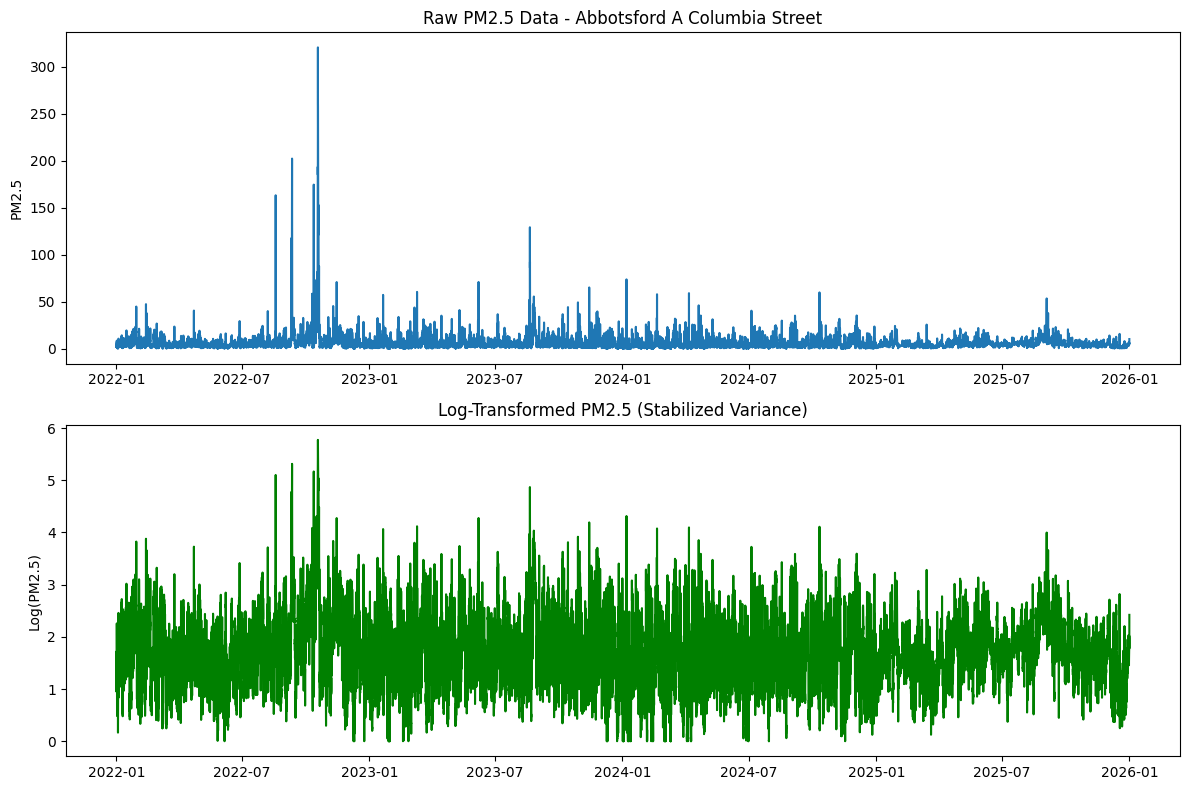


--- Augmented Dickey-Fuller (ADF) Test ---
ADF Statistic: -17.3318
p-value:       5.4047e-30
✅ Result: Stationary (p < 0.05). d=0 might be okay.

--- Seasonal Decomposition (2 Weeks Zoom) ---


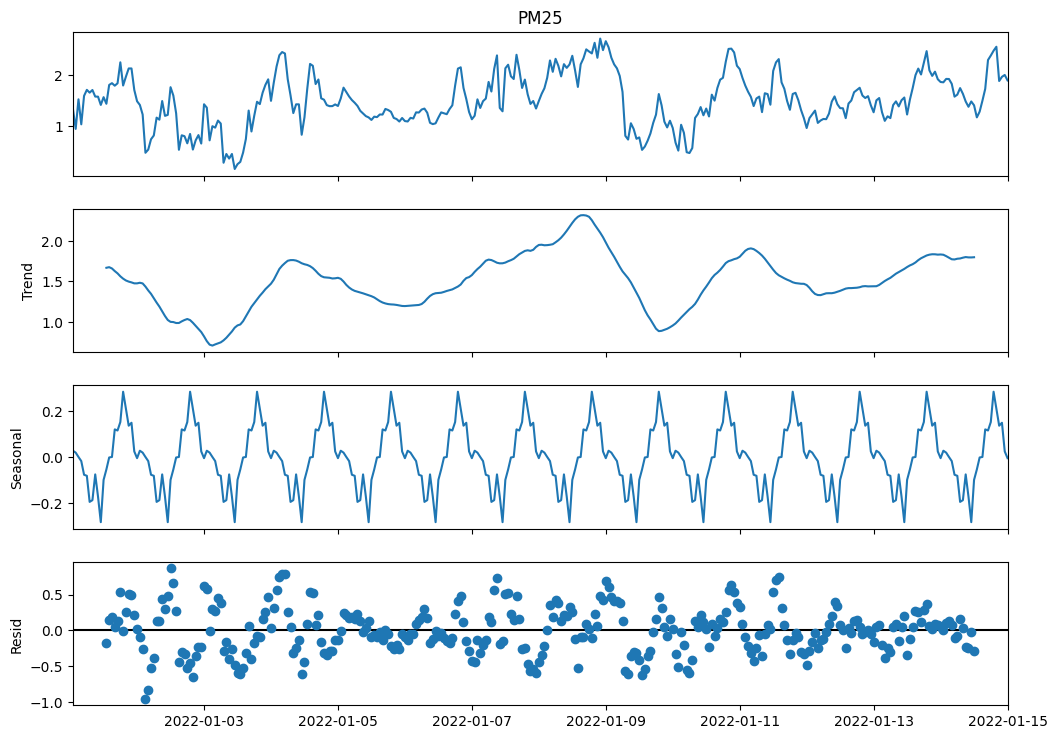


--- ACF & PACF Plots (Checking Lags) ---


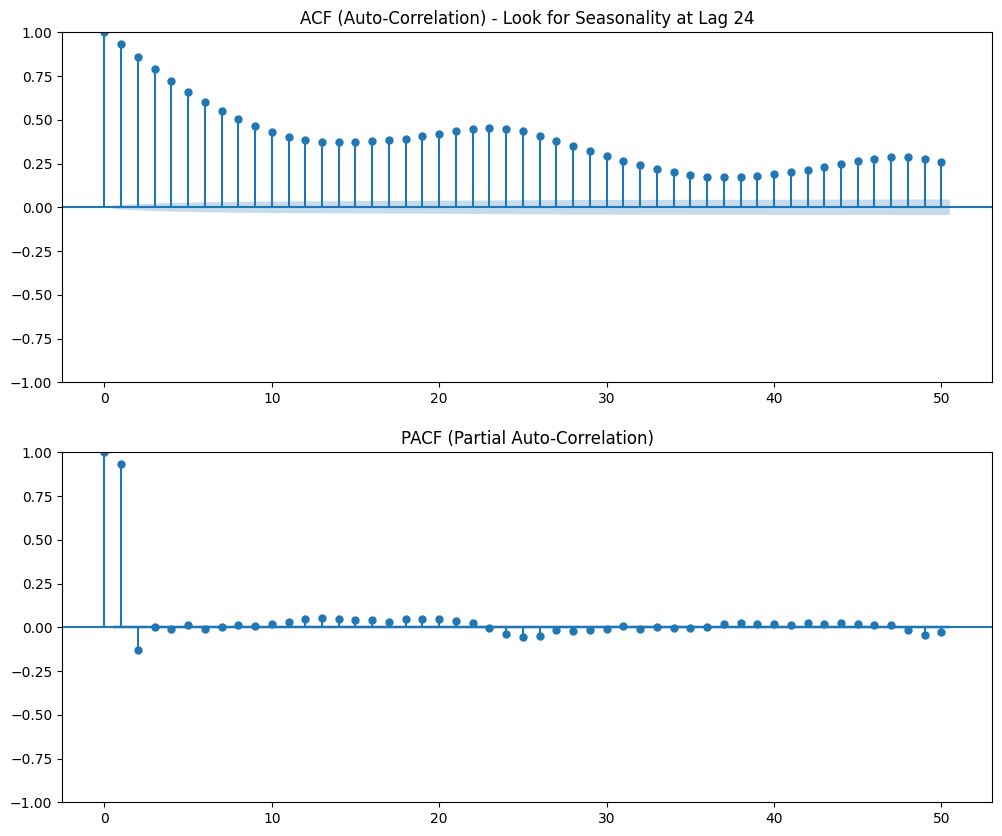

In [18]:
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
import numpy as np

# ---------------------------------------------------------
# 1. Select a Sample Station
# ---------------------------------------------------------
# Let's pick the first station in the list
sample_station = full_imputed_data['Station'].unique()[0]
print(f"🔬 Analyzing Station: {sample_station}")

# Extract Time Series (Ensure it's sorted and indexed by time)
df_sample = full_imputed_data[full_imputed_data['Station'] == sample_station].copy()
df_sample = df_sample.set_index('Datetime').sort_index()
ts = df_sample['PM25']

# ---------------------------------------------------------
# 2. Visual Inspection (Raw vs Log)
# ---------------------------------------------------------
fig, ax = plt.subplots(2, 1, figsize=(12, 8))

# Plot A: Raw Data
ax[0].plot(ts)
ax[0].set_title(f'Raw PM2.5 Data - {sample_station}')
ax[0].set_ylabel('PM2.5')

# Plot B: Log Transformed Data (Recommended for Air Quality)
# We use log1p (log(x+1)) to handle zero values
ts_log = np.log1p(ts)
ax[1].plot(ts_log, color='green')
ax[1].set_title('Log-Transformed PM2.5 (Stabilized Variance)')
ax[1].set_ylabel('Log(PM2.5)')

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 3. Stationarity Test (ADF Test)
# ---------------------------------------------------------
print("\n--- Augmented Dickey-Fuller (ADF) Test ---")
# Test on LOG transformed data (usually what you will model)
result = adfuller(ts_log)
print(f"ADF Statistic: {result[0]:.4f}")
print(f"p-value:       {result[1]:.4e}")  # Scientific notation for very small numbers

if result[1] < 0.05:
    print("✅ Result: Stationary (p < 0.05). d=0 might be okay.")
else:
    print("⚠️ Result: Non-Stationary (p > 0.05). You MUST use differencing (d=1).")

# ---------------------------------------------------------
# 4. Seasonality Decomposition
# ---------------------------------------------------------
# We check a small window (e.g., 2 weeks) to see the daily pattern clearly
print("\n--- Seasonal Decomposition (2 Weeks Zoom) ---")
decomp_sample = ts_log.iloc[:24*14]  # First 14 days
decomposition = seasonal_decompose(decomp_sample, model='additive', period=24)

fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.show() 

# ---------------------------------------------------------
# 5. ACF and PACF Plots (To find p, q, P, Q)
# ---------------------------------------------------------
print("\n--- ACF & PACF Plots (Checking Lags) ---")
fig, ax = plt.subplots(2, 1, figsize=(12, 10))

# Standard ACF (Auto-Correlation)
# Look for spikes at 24, 48, 72 -> confirms Seasonality (s=24)
plot_acf(ts_log, lags=50, ax=ax[0], title="ACF (Auto-Correlation) - Look for Seasonality at Lag 24")

# Standard PACF (Partial Auto-Correlation)
plot_pacf(ts_log, lags=50, ax=ax[1], title="PACF (Partial Auto-Correlation)")

plt.show()

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pmdarima as pm
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

train_data = ts_log

model_search = pm.auto_arima(
    train_data,
    m=24,                 # 每日週期
    seasonal=True,        # 啟用季節性
    d=0,                  # 強制 d=0 (因為已經平穩)
    start_p=1, max_p=3,   # 根據 PACF 圖，AR(1) 或 AR(2) 很有可能
    start_q=0, max_q=3,
    start_P=0, max_P=2,   # 季節性 AR
    start_Q=0, max_Q=2,
    D=None,               # 讓模型自動判斷是否需要季節性差分 (通常 D=1)
    max_order=6,          # 防止模型過度複雜
    stepwise=True,        # 快速搜尋
    error_action='ignore',
    suppress_warnings=True,
    trace=True            # 顯示過程
)

best_order = model_search.order
best_seasonal = model_search.seasonal_order
print(f"\n找到最佳參數: Order={best_order}, Seasonal={best_seasonal}")


# ==========================================
# 3. 全量訓練 (使用找到的參數訓練大數據)
# ==========================================
print("\n--- 階段二：使用最佳參數訓練最終模型 ---")

# 建議：訓練資料用最近 1~2 年 (約 17520 筆) 效果通常比用 4 年好
# 因為 2022 的污染模式可能跟 2026 不太一樣
train_final = ts_log.tail(17520) 

final_model = SARIMAX(
    train_final,
    order=best_order,
    seasonal_order=best_seasonal,
    enforce_stationarity=False,
    enforce_invertibility=False
)

results = final_model.fit()
print(results.summary())


# ==========================================
# 4. 預測與還原 (Log -> Original)
# ==========================================
# 預測未來 24 小時
forecast_log = results.get_forecast(steps=24)
mean_log = forecast_log.predicted_mean
conf_int_log = forecast_log.conf_int()

# *** 重要：將 Log 數值轉回原始 PM2.5 濃度 ***
forecast_val = np.expm1(mean_log)  # 對應 log1p 的反函數是 expm1
conf_int_val = np.expm1(conf_int_log)

print("\n未來 24 小時預測值 (PM2.5):")
print(forecast_val)

# 簡單繪圖
plt.figure(figsize=(12, 6))
# 畫出最近 72 小時的實際值
plt.plot(df.index[-72:], df['PM25_Column'].tail(72), label='Actual')
# 畫出預測值
plt.plot(mean_log.index, forecast_val, label='Forecast', color='red')
plt.title('PM2.5 Forecast (Next 24 Hours)')
plt.legend()
plt.show()

Performing stepwise search to minimize aic
 ARIMA(1,0,0)(0,0,0)[24] intercept   : AIC=-2527.799, Time=1.17 sec
 ARIMA(0,0,0)(0,0,0)[24] intercept   : AIC=70595.042, Time=3.08 sec
 ARIMA(1,0,0)(1,0,0)[24] intercept   : AIC=-2904.032, Time=94.52 sec
 ARIMA(0,0,1)(0,0,1)[24] intercept   : AIC=32903.488, Time=95.02 sec
 ARIMA(0,0,0)(0,0,0)[24]             : AIC=139994.909, Time=0.27 sec


KeyboardInterrupt: 

In [42]:
df_sample

,Station,PM25,Latitude,Longitude
Datetime,,,,
2022-01-01 01:00:00,Abbotsford A Columbia Street,2.840752,49.0215,-122.3265
2022-01-01 02:00:00,Abbotsford A Columbia Street,1.589611,49.0215,-122.3265
2022-01-01 03:00:00,Abbotsford A Columbia Street,3.624472,49.0215,-122.3265
2022-01-01 04:00:00,Abbotsford A Columbia Street,1.832389,49.0215,-122.3265
2022-01-01 05:00:00,Abbotsford A Columbia Street,3.949861,49.0215,-122.3265
...,...,...,...,...
2025-12-31 20:00:00,Abbotsford A Columbia Street,5.797992,49.0215,-122.3265
2025-12-31 21:00:00,Abbotsford A Columbia Street,5.212566,49.0215,-122.3265
2025-12-31 22:00:00,Abbotsford A Columbia Street,6.207502,49.0215,-122.3265


C:\Users\User\AppData\Local\Temp\ipykernel_63252\47426487.py:27: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_station = df_station.asfreq('H')


鎖定測站: Abbotsford A Columbia Street
資料範圍: 2022-01-01 01:00:00 到 2026-01-01 00:00:00

--- 執行 STL 分解 (去除季節性看趨勢) ---


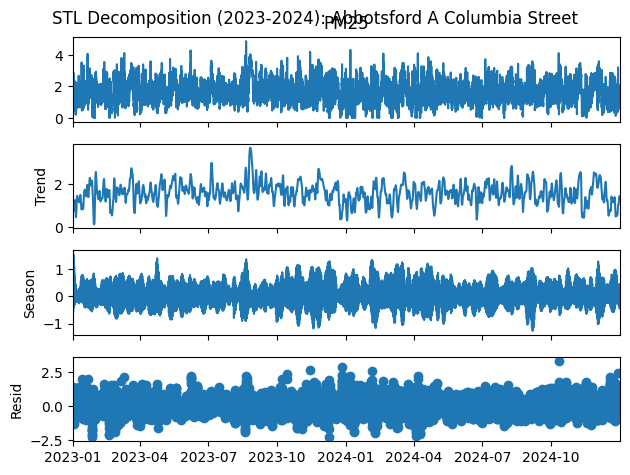


--- 搜尋最佳 ARIMA 參數 (使用 2024 最後 2 個月數據加速) ---
最佳參數: Order=(1, 1, 0), Seasonal=(2, 0, 0, 24)

--- 訓練最終模型 (2023-2024) ---
                                     SARIMAX Results                                      
Dep. Variable:                               PM25   No. Observations:                17544
Model:             SARIMAX(1, 1, 0)x(2, 0, 0, 24)   Log Likelihood               -1341.022
Date:                            Wed, 11 Feb 2026   AIC                           2690.043
Time:                                    03:43:39   BIC                           2721.122
Sample:                                01-01-2023   HQIC                          2700.277
                                     - 12-31-2024                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------

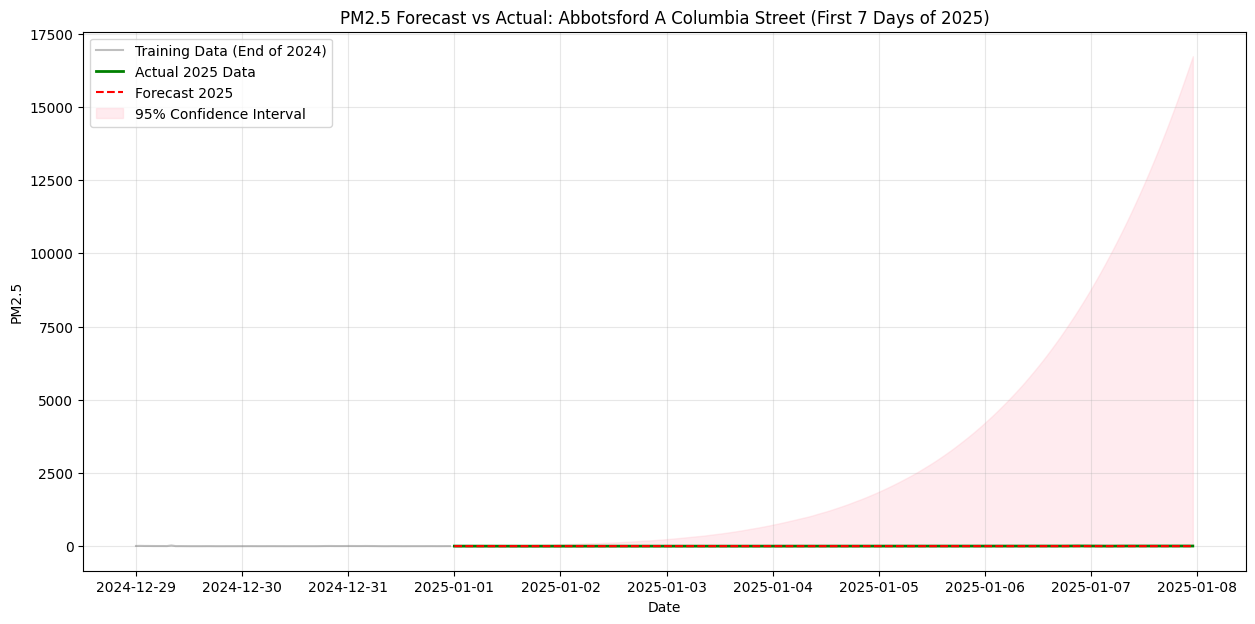

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pmdarima as pm
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import STL
from sklearn.metrics import mean_squared_error

# ==========================================
# 0. 資料前處理 (針對您的 df_sample 格式)
# ==========================================
# 假設您的資料框叫 df_sample
df = df_sample.copy()

# 確保 Index 是時間格式
if not isinstance(df.index, pd.DatetimeIndex):
    df.index = pd.to_datetime(df['Datetime']) # 如果 Datetime 是欄位不是 index
    df = df.set_index('Datetime', drop=False) # 保持 Datetime 欄位存在以便檢查

# **關鍵步驟**：確保只分析「單一測站」
# 如果您的資料有多個測站，混在一起跑 Time Series 會出錯
station_name = df['Station'].iloc[0] # 自動抓取第一個測站名稱
df_station = df[df['Station'] == station_name].copy()

# 確保時間序列連續 (填補缺失值)
# 設頻率為 'H' (小時)，並用線性插值補齊中間斷掉的數據
df_station = df_station.asfreq('H')
df_station['PM25'] = df_station['PM25'].interpolate(method='linear')

print(f"鎖定測站: {station_name}")
print(f"資料範圍: {df_station.index.min()} 到 {df_station.index.max()}")

# ==========================================
# 1. 切分訓練集 (2023-2024) 與 測試集 (2025)
# ==========================================
# 訓練集：嚴格鎖定 2023 ~ 2024
train_df = df_station.loc['2023-01-01':'2024-12-31'].copy()

# 測試集：2025 年 (用來驗證預測準不準)
test_df = df_station.loc['2025-01-01':].copy()

# Log 轉換 (穩定變異數，避免極端值影響)
train_log = np.log1p(train_df['PM25'])

# ==========================================
# 2. STL Decomposition (觀察 23-24 趨勢)
# ==========================================
print("\n--- 執行 STL 分解 (去除季節性看趨勢) ---")
stl = STL(train_log, period=24, robust=True)
res_stl = stl.fit()

# 畫出分解圖
fig = res_stl.plot()
plt.suptitle(f'STL Decomposition (2023-2024): {station_name}', fontsize=12)
plt.show()

# ==========================================
# 3. Auto ARIMA 參數搜尋
# ==========================================
print("\n--- 搜尋最佳 ARIMA 參數 (使用 2024 最後 2 個月數據加速) ---")

# 為了節省時間，只用最後 60 天 (1440 小時) 來找參數 p,d,q
search_data = train_log.tail(24 * 60)

model_search = pm.auto_arima(
    search_data,
    m=24,                 # 日週期
    seasonal=True,
    d=None,               # 自動判斷差分
    start_p=1, max_p=3,
    start_q=0, max_q=3,
    start_P=0, max_P=2,
    start_Q=0, max_Q=2,
    max_order=6,
    stepwise=True,
    suppress_warnings=True,
    error_action='ignore'
)

best_order = model_search.order
best_seasonal = model_search.seasonal_order
print(f"最佳參數: Order={best_order}, Seasonal={best_seasonal}")

# ==========================================
# 4. 全量訓練 (使用 2023-2024 完整數據)
# ==========================================
print("\n--- 訓練最終模型 (2023-2024) ---")

final_model = SARIMAX(
    train_log,
    order=best_order,
    seasonal_order=best_seasonal,
    enforce_stationarity=False,
    enforce_invertibility=False
)

results = final_model.fit()
print(results.summary())

# ==========================================
# 5. 預測 2025 並與真實數據對比
# ==========================================
# 設定預測長度 (例如：預測 2025 的前 7 天)
# 如果要預測整年，steps = len(test_df)，但會非常慢且失準
predict_days = 7
steps = 24 * predict_days 

print(f"\n--- 預測 2025 前 {predict_days} 天 ---")

forecast_log = results.get_forecast(steps=steps)
mean_log = forecast_log.predicted_mean
conf_int_log = forecast_log.conf_int()

# 還原數值 (Log -> Original)
forecast_val = np.expm1(mean_log)
conf_int_val = np.expm1(conf_int_log)

# 取出對應時間段的「真實數據」來比較
actual_2025 = test_df['PM25'].head(steps)

# 計算誤差 (RMSE)
rmse = np.sqrt(mean_squared_error(actual_2025, forecast_val))
print(f"預測誤差 (RMSE): {rmse:.4f}")

# ==========================================
# 6. 成果繪圖
# ==========================================
plt.figure(figsize=(15, 7))

# 1. 畫出訓練集最後一段 (2024 年底)
plt.plot(train_df.index[-72:], train_df['PM25'].tail(72), label='Training Data (End of 2024)', color='gray', alpha=0.5)

# 2. 畫出 2025 真實數據
plt.plot(actual_2025.index, actual_2025, label='Actual 2025 Data', color='green', linewidth=2)

# 3. 畫出 2025 預測數據
plt.plot(forecast_val.index, forecast_val, label='Forecast 2025', color='red', linestyle='--')

# 4. 畫出信賴區間
plt.fill_between(forecast_val.index,
                 conf_int_val.iloc[:, 0],
                 conf_int_val.iloc[:, 1],
                 color='pink', alpha=0.3, label='95% Confidence Interval')

plt.title(f'PM2.5 Forecast vs Actual: {station_name} (First {predict_days} Days of 2025)')
plt.xlabel('Date')
plt.ylabel('PM2.5')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [24]:
import sys
!{sys.executable} -m pip install pygam

  Using cached pygam-0.12.0-py3-none-any.whl.metadata (9.8 kB)
  Using cached progressbar2-4.5.0-py3-none-any.whl.metadata (16 kB)
  Using cached python_utils-3.9.1-py2.py3-none-any.whl.metadata (9.8 kB)
Using cached pygam-0.12.0-py3-none-any.whl (84 kB)
Using cached progressbar2-4.5.0-py3-none-any.whl (57 kB)
Using cached python_utils-3.9.1-py2.py3-none-any.whl (32 kB)

   ------------- -------------------------- 1/3 [progressbar2]
   ------------- -------------------------- 1/3 [progressbar2]
   -------------------------- ------------- 2/3 [pygam]
   ---------------------------------------- 3/3 [pygam]



  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [27]:
df_all = pd.DataFrame({'y': ts_log.values}, index=ts_log.index)
df_all

,y
Datetime,
2022-01-01 01:00:00,1.345668
2022-01-01 02:00:00,0.951508
2022-01-01 03:00:00,1.531362
2022-01-01 04:00:00,1.041121
2022-01-01 05:00:00,1.599359
...,...
2025-12-31 20:00:00,1.916627
2025-12-31 21:00:00,1.826574
2025-12-31 22:00:00,1.975122


--- 正在訓練 XGBoost ---
[0]	validation_0-rmse:0.70802	validation_1-rmse:0.71518
[100]	validation_0-rmse:0.60486	validation_1-rmse:0.67145
[200]	validation_0-rmse:0.57537	validation_1-rmse:0.67078
[205]	validation_0-rmse:0.57435	validation_1-rmse:0.67125

--- 執行遞歸預測 ---
XGBoost RMSE: 3.5345


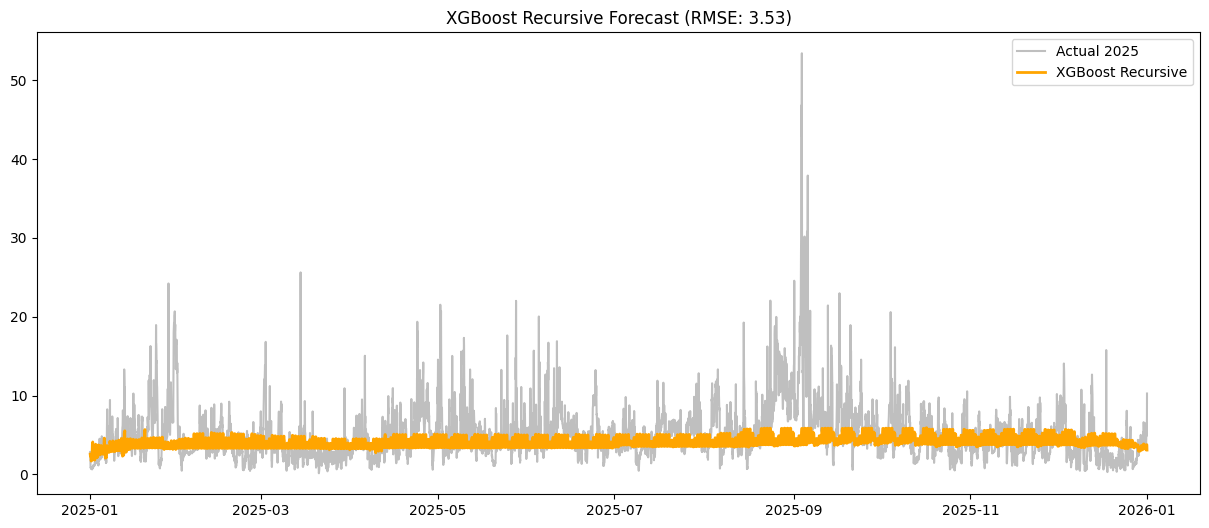

In [38]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# --- 1. 資料準備與特徵工程 ---
df = pd.DataFrame({'y': ts_log.values}, index=ts_log.index)

# 建立特徵函數 (Feature Engineering)
def create_features(data):
    data = data.copy()
    data['hour'] = data.index.hour
    data['dayofweek'] = data.index.dayofweek
    data['quarter'] = data.index.quarter
    data['month'] = data.index.month
    data['dayofyear'] = data.index.dayofyear
    # 重要：加入 Lag 特徵 (昨天同一時間的數值)
    # 注意：在遞歸預測時，這個 Lag 會被我們的預測值填補
    data['lag_24'] = data['y'].shift(24)
    return data

df_features = create_features(df)
df_features = df_features.dropna() # 移除因為 shift 產生的空值

# --- 2. 劃分訓練集與測試集 ---
split_date = '2025-01-01'
train = df_features.loc[df_features.index < split_date].copy()
test = df_features.loc[df_features.index >= split_date].copy()

# 分離特徵 (X) 與 目標 (y)
FEATURES = ['hour', 'dayofweek', 'quarter', 'month', 'dayofyear', 'lag_24']
TARGET = 'y'

X_train = train[FEATURES]
y_train = train[TARGET]
X_test = test[FEATURES].copy() # 這裡我們後面會動態修改它
y_test = test[TARGET]

# --- 3. 訓練 XGBoost 模型 ---
print("--- 正在訓練 XGBoost ---")
reg = xgb.XGBRegressor(
    n_estimators=1000,      # 樹的數量
    learning_rate=0.01,     # 學習率 (越低越慢但越精細)
    max_depth=6,            # 樹的深度 (太深會 overfitting)
    early_stopping_rounds=50,
    objective='reg:squarederror' # 回歸任務
)

# 這裡需要 validation set 來做 early stopping
# 我們簡單切分訓練集的最後 10% 做驗證
split_idx = int(len(X_train) * 0.9)
X_tr, y_tr = X_train.iloc[:split_idx], y_train.iloc[:split_idx]
X_val, y_val = X_train.iloc[split_idx:], y_train.iloc[split_idx:]

reg.fit(X_tr, y_tr,
        eval_set=[(X_tr, y_tr), (X_val, y_val)],
        verbose=100) # 每 100 次迭代顯示一次

# --- 4. 遞歸預測 (Recursive Loop) ---
# 這是最關鍵的一步：因為我們沒有未來的 'lag_24'，我們要自己生成它
print("\n--- 執行遞歸預測 ---")

test_predictions = []
current_data = df_features.iloc[len(train):].copy() # 拿到測試集的特徵結構

# 為了模擬真實情況，我們假設要在測試集開始前，取得最後 24 小時的真實數據作為起點
last_window = train['y'].tail(24).values.tolist() 

# 逐小時預測
for i in range(len(test)):
    # 1. 取得當前時間點的特徵
    current_row = X_test.iloc[[i]].copy()
    
    # 2. 填補 lag_24 (如果是預測未來，這裡就要用我們之前的預測值)
    # 邏輯：如果 i < 24，我們還可以用真實的歷史數據(在 last_window 裡)
    # 如果 i >= 24，我們必須用 24 小時前預測出來的值
    if i < 24:
        lag_val = last_window[i]
    else:
        lag_val = test_predictions[i - 24] # 用自己 24 小時前預測的值
        
    current_row['lag_24'] = lag_val
    
    # 3. 預測
    pred = reg.predict(current_row)[0]
    test_predictions.append(pred)

# --- 5. 繪圖與還原 ---
test['prediction_log'] = test_predictions
# 還原 log (假設原始數據用 np.log1p)
test['prediction'] = np.expm1(test['prediction_log'])
test['actual'] = np.expm1(test['y'])

rmse = np.sqrt(mean_squared_error(test['actual'], test['prediction']))
print(f"XGBoost RMSE: {rmse:.4f}")

plt.figure(figsize=(15, 6))
plt.plot(test.index, test['actual'], label='Actual 2025', alpha=0.5, color='gray')
plt.plot(test.index, test['prediction'], label='XGBoost Recursive', color='orange', linewidth=2)
plt.title(f'XGBoost Recursive Forecast (RMSE: {rmse:.2f})')
plt.legend()
plt.show()

c:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


--- 正在訓練 Prophet ---


03:13:47 - cmdstanpy - INFO - Chain [1] start processing
03:14:02 - cmdstanpy - INFO - Chain [1] done processing
c:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\prophet\forecaster.py:1875: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  dates = pd.date_range(


Prophet RMSE: 3.4421


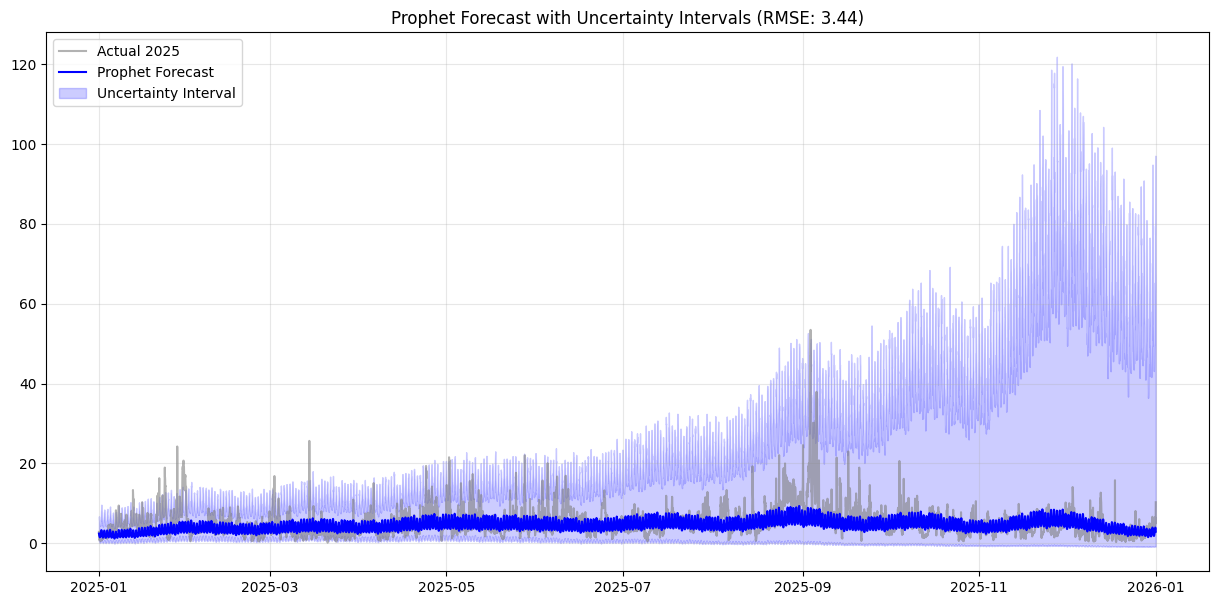

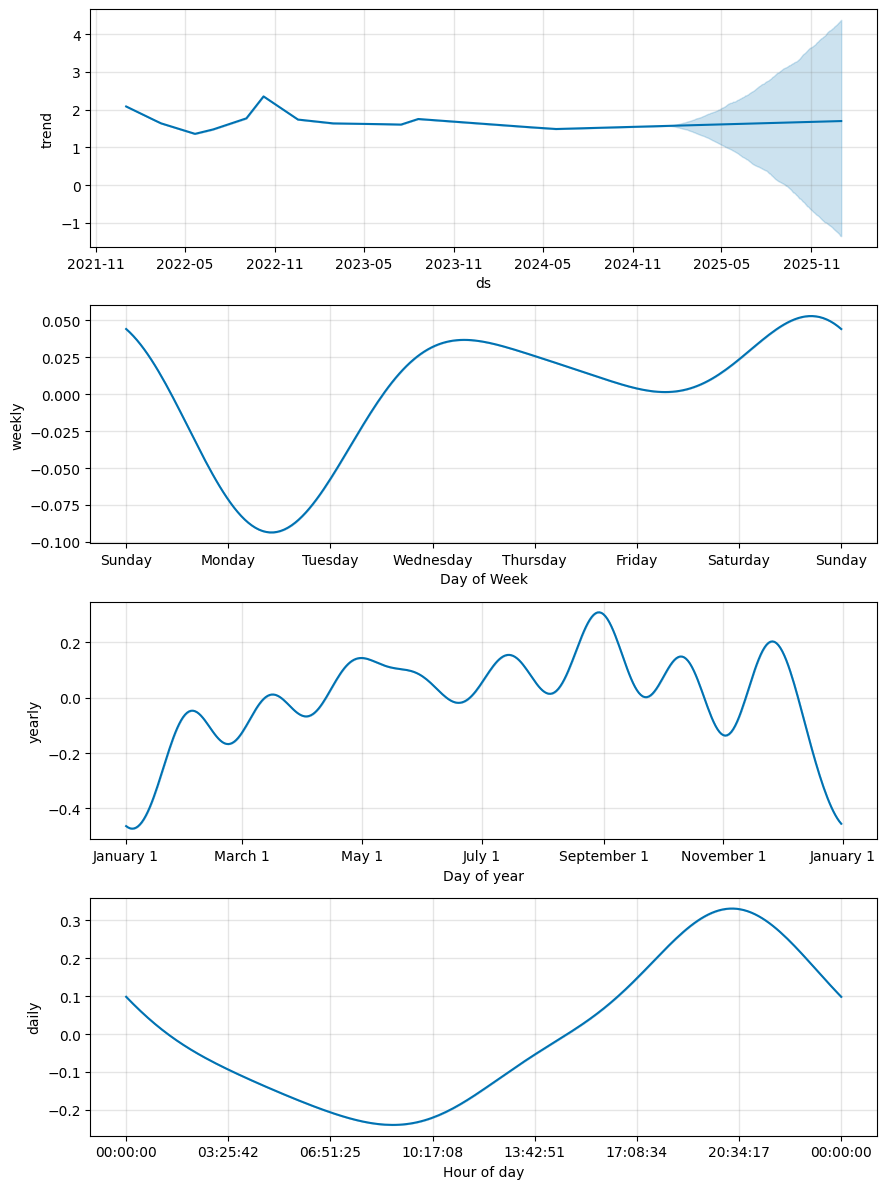

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
from sklearn.metrics import mean_squared_error

# --- 1. 資料格式轉換 ---
# Prophet 嚴格要求欄位名稱：ds (datetime), y (value)
df_prophet = pd.DataFrame()
df_prophet['ds'] = ts_log.index
df_prophet['y'] = ts_log.values # 這裡依然用 log 值訓練，保證數值穩定

# 劃分訓練集
train_prophet = df_prophet[df_prophet['ds'] < '2025-01-01']
test_prophet = df_prophet[df_prophet['ds'] >= '2025-01-01']

# --- 2. 建立與訓練 Prophet 模型 ---
print("--- 正在訓練 Prophet ---")

# 參數調整關鍵：
# changepoint_prior_scale: 數值越大，模型對趨勢變化越敏感 (越不像直線，但也越容易過擬合)
# seasonality_mode: 'multiplicative' 通常更適合空氣品質 (基數大時波動也大)
m = Prophet(
    changepoint_prior_scale=0.1, 
    daily_seasonality=True,
    weekly_seasonality=True,
    yearly_seasonality=True,
    seasonality_mode='additive' # 若 log 轉換過，用 additive 即可；若無，用 multiplicative
)

# 加入國家節假日 (雖然對 PM2.5 影響可能不如交通模式大，但在長假期間可能有效)
# m.add_country_holidays(country_name='TW') # 如果你在台灣

m.fit(train_prophet)

# --- 3. 建立未來時間表 ---
# 預測長度 = 測試集的長度
future = m.make_future_dataframe(periods=len(test_prophet), freq='H')

# --- 4. 預測 ---
forecast = m.predict(future)

# --- 5. 資料還原與合併 ---
# 取出預測部分的結果
forecast_test = forecast.iloc[-len(test_prophet):].copy()

# 還原 Log
y_pred = np.expm1(forecast_test['yhat'].values)
y_pred_lower = np.expm1(forecast_test['yhat_lower'].values) # 信心下限
y_pred_upper = np.expm1(forecast_test['yhat_upper'].values) # 信心上限
y_true = np.expm1(test_prophet['y'].values)

# --- 6. 繪圖 (包含信心區間) ---
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
print(f"Prophet RMSE: {rmse:.4f}")

plt.figure(figsize=(15, 7))

# 畫真實值
plt.plot(test_prophet['ds'], y_true, label='Actual 2025', color='gray', alpha=0.6)

# 畫預測中位數
plt.plot(test_prophet['ds'], y_pred, label='Prophet Forecast', color='blue')

# 畫信心區間 (這才是 Prophet 的價值所在)
plt.fill_between(test_prophet['ds'], y_pred_lower, y_pred_upper, color='blue', alpha=0.2, label='Uncertainty Interval')

plt.title(f'Prophet Forecast with Uncertainty Intervals (RMSE: {rmse:.2f})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 額外：畫出成分分解圖 (看看趨勢、日週期、年週期)
fig2 = m.plot_components(forecast)
plt.show()

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error

# --- 資料準備 ---
# 假設 df_all 已經整理好，且 index 是 DateTime
# SARIMA 非常依賴時間頻率的完整性
df_all = df_all.asfreq('H').fillna(method='ffill')

# 劃分訓練集
train_data = df_all[df_all.index.year < 2025]['y']
test_data = df_all[df_all.index.year == 2025]['y']

# --- 訓練 SARIMA 模型 ---
# 參數說明：
# order=(p,d,q): 非季節性參數 (自動回歸, 差分, 移動平均)
# seasonal_order=(P,D,Q,s): 季節性參數, s=24 代表日週期
print("正在訓練 SARIMA 模型 (這可能會跑很久)...")


# 這裡的參數 (1,0,0)x(1,1,1,24) 只是經驗值，通常需要 auto_arima 跑很久去抓
model = SARIMAX(train_data, 
                order=(1, 0, 1), 
                seasonal_order=(1, 1, 1, 24),
                enforce_stationarity=False,
                enforce_invertibility=False)

results = model.fit()
print(results.summary())

# --- 預測未來 ---
# 預測 2025 年 1 月 (假設預測 744 小時)
steps = 744
forecast = results.get_forecast(steps=steps)
forecast_mean_log = forecast.predicted_mean
conf_int = forecast.conf_int()

# --- 還原數值 ---
forecast_val = np.expm1(forecast_mean_log)
actual_val = np.expm1(test_data.iloc[:steps])
lower_bound = np.expm1(conf_int.iloc[:, 0])
upper_bound = np.expm1(conf_int.iloc[:, 1])

# --- 繪圖 ---
plt.figure(figsize=(15, 6))
plt.plot(actual_val.index, actual_val, label='Actual 2025', color='gray', alpha=0.5)
plt.plot(forecast_val.index, forecast_val, label='SARIMA Forecast', color='green')
plt.fill_between(forecast_val.index, lower_bound, upper_bound, color='green', alpha=0.1, label='Confidence Interval')
plt.title('SARIMA Forecast')
plt.legend()
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_63252\803271009.py:10: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_all = df_all.asfreq('H').fillna(method='ffill')
C:\Users\User\AppData\Local\Temp\ipykernel_63252\803271009.py:10: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_all = df_all.asfreq('H').fillna(method='ffill')


正在訓練 SARIMA 模型 (這可能會跑很久)...


KeyboardInterrupt: 

In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# --- 1. 資料準備與特徵工程 ---
df = pd.DataFrame({'y': ts_log.values}, index=ts_log.index)

# 建立特徵函數 (Feature Engineering)
def create_features(data):
    data = data.copy()
    data['hour'] = data.index.hour
    data['dayofweek'] = data.index.dayofweek
    data['quarter'] = data.index.quarter
    data['month'] = data.index.month
    data['dayofyear'] = data.index.dayofyear
    # 重要：加入 Lag 特徵 (昨天同一時間的數值)
    # 注意：在遞歸預測時，這個 Lag 會被我們的預測值填補
    data['lag_24'] = data['y'].shift(24)
    return data

df_features = create_features(df)
df_features = df_features.dropna() # 移除因為 shift 產生的空值

# --- 2. 劃分訓練集與測試集 ---
split_date = '2025-01-01'
train = df_features.loc[df_features.index < split_date].copy()
test = df_features.loc[df_features.index >= split_date].copy()

# 分離特徵 (X) 與 目標 (y)
FEATURES = ['hour', 'dayofweek', 'quarter', 'month', 'dayofyear', 'lag_24']
TARGET = 'y'

X_train = train[FEATURES]
y_train = train[TARGET]
X_test = test[FEATURES].copy() # 這裡我們後面會動態修改它
y_test = test[TARGET]

# --- 3. 訓練 XGBoost 模型 ---
print("--- 正在訓練 XGBoost ---")
reg = xgb.XGBRegressor(
    n_estimators=1000,      # 樹的數量
    learning_rate=0.01,     # 學習率 (越低越慢但越精細)
    max_depth=6,            # 樹的深度 (太深會 overfitting)
    early_stopping_rounds=50,
    objective='reg:squarederror' # 回歸任務
)

# 這裡需要 validation set 來做 early stopping
# 我們簡單切分訓練集的最後 10% 做驗證
split_idx = int(len(X_train) * 0.9)
X_tr, y_tr = X_train.iloc[:split_idx], y_train.iloc[:split_idx]
X_val, y_val = X_train.iloc[split_idx:], y_train.iloc[split_idx:]

reg.fit(X_tr, y_tr,
        eval_set=[(X_tr, y_tr), (X_val, y_val)],
        verbose=100) # 每 100 次迭代顯示一次

# --- 4. 遞歸預測 (Recursive Loop) ---
# 這是最關鍵的一步：因為我們沒有未來的 'lag_24'，我們要自己生成它
print("\n--- 執行遞歸預測 ---")

test_predictions = []
current_data = df_features.iloc[len(train):].copy() # 拿到測試集的特徵結構

# 為了模擬真實情況，我們假設要在測試集開始前，取得最後 24 小時的真實數據作為起點
last_window = train['y'].tail(24).values.tolist() 

# 逐小時預測
for i in range(len(test)):
    # 1. 取得當前時間點的特徵
    current_row = X_test.iloc[[i]].copy()
    
    # 2. 填補 lag_24 (如果是預測未來，這裡就要用我們之前的預測值)
    # 邏輯：如果 i < 24，我們還可以用真實的歷史數據(在 last_window 裡)
    # 如果 i >= 24，我們必須用 24 小時前預測出來的值
    if i < 24:
        lag_val = last_window[i]
    else:
        lag_val = test_predictions[i - 24] # 用自己 24 小時前預測的值
        
    current_row['lag_24'] = lag_val
    
    # 3. 預測
    pred = reg.predict(current_row)[0]
    test_predictions.append(pred)

# --- 5. 繪圖與還原 ---
test['prediction_log'] = test_predictions
# 還原 log (假設原始數據用 np.log1p)
test['prediction'] = np.expm1(test['prediction_log'])
test['actual'] = np.expm1(test['y'])

rmse = np.sqrt(mean_squared_error(test['actual'], test['prediction']))
print(f"XGBoost RMSE: {rmse:.4f}")

plt.figure(figsize=(15, 6))
plt.plot(test.index, test['actual'], label='Actual 2025', alpha=0.5, color='gray')
plt.plot(test.index, test['prediction'], label='XGBoost Recursive', color='orange', linewidth=2)
plt.title(f'XGBoost Recursive Forecast (RMSE: {rmse:.2f})')
plt.legend()
plt.show()

# Section 2: EDA

# Section 3: Feature Engineering

# Section 4: Modeling

# Section 5: Recommendation

# Section 6: Limitation